<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment12/DNN_Assignment_12_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install torchmetrics
!pip install torchinfo
import os
import random
import torch
import numpy as np
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import MulticlassAccuracy
import torch.optim as optim
from tqdm import tqdm
import time
from torchinfo import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [2]:
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
val_ratio = 0.1
generator = torch.Generator().manual_seed(seed)
use_reduced_data = True

transform = transforms.Compose([
    transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation((-30, 30)),
    # transforms.ColorJitter(),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transformTest = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

CIFAR10Dataset = torchvision.datasets.CIFAR10(root='.', download=True)
full_train_dataset = torchvision.datasets.CIFAR10(root='.', train=True, download=True, transform=None)
test_dataset = torchvision.datasets.CIFAR10(root='.', train=False, download=True, transform=transformTest)

if use_reduced_data:
    total_reduced_size = 10000
    selected_indices = torch.randperm(len(full_train_dataset), generator=generator)[:total_reduced_size]
else:
    selected_indices = torch.arange(len(full_train_dataset))

val_size = int(len(selected_indices) * val_ratio)
train_size = len(selected_indices) - val_size
train_indices, val_indices = random_split(selected_indices, [train_size, val_size], generator=generator)


train_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transform),
    train_indices.indices
)

val_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transformTest),
    val_indices.indices
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())


100%|██████████| 170M/170M [00:12<00:00, 14.1MB/s]


In [3]:
import torch.nn as nn
from torchvision.models import resnet101

def get_resnet101(num_classes=10):
    model = resnet101(pretrained=True)

    # Modify first conv and remove maxpool for small images (32x32)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last few layers in layer4 and fc
    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    # Replace final classification layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

resnet101_model = get_resnet101().to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:01<00:00, 157MB/s]


In [4]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SmallCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
student = SmallCNN().to(device)

In [5]:
def train(model, train_loader, val_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    model.to(device)
    results = []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        start_time = time.time()

        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        val_acc, val_loss = validation(model, val_loader, device, show_metrics=False)
        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs}({time.time() - start_time:.2f}s)  - accuracy: {train_acc:.4f}  - loss: {train_loss:.4f}  - val_accuracy: {val_acc:.4f}  - val_loss: {val_loss:.4f}")
        results.append([train_acc, train_loss, val_acc, val_loss])
    return results

def validation(model, test_loader, device, show_metrics=True):
    metric = MulticlassAccuracy(num_classes=10).to(device)
    model.eval()
    model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in (test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            metric.update(outputs, labels)
            total_loss += loss.item()

    accuracy_val = metric.compute().item()
    avg_loss = total_loss / len(test_loader)

    if show_metrics:
        print(f"Validation Accuracy: {accuracy_val:.4f} Loss: {avg_loss:.4f}")
    return accuracy_val, avg_loss


def train_knowledge_distillation(teacher, student, train_loader, val_loader, epochs, learning_rate, T, alpha, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(student.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    teacher.eval()  # Teacher set to evaluation mode
    student.train() # Student to train mode

    results = []

    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        start_time = time.time()
        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                teacher_logits = teacher(inputs)
            student_logits = student(inputs)

            label_loss = criterion(student_logits, labels)
            soft_prob = nn.functional.log_softmax(student_logits / T, dim=-1)
            soft_targets = nn.functional.softmax(teacher_logits / T, dim=-1)
            soft_targets_loss = F.kl_div(soft_prob, soft_targets, reduction='batchmean') * (T ** 2)
            loss = alpha * soft_targets_loss + (1 - alpha) * label_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(student_logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        val_acc, val_loss = validation(student, val_loader, device, show_metrics=False)
        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs}({time.time() - start_time:.2f}s) - accuracy: {train_acc:.4f}  - loss: {train_loss:.4f}  - val_accuracy: {val_acc:.4f}  - val_loss: {val_loss:.4f}")
        results.append([train_acc, train_loss, val_acc, val_loss])
    return results


In [6]:
epochs = 20
learning_rate = 1e-3
history_resnet101 = train(resnet101_model, train_loader, val_loader, epochs, learning_rate, device)
validation(resnet101_model, test_loader, device)

Epoch 1/20(20.61s)  - accuracy: 0.3816  - loss: 1.8489  - val_accuracy: 0.5328  - val_loss: 1.4977
Epoch 2/20(19.66s)  - accuracy: 0.4844  - loss: 1.6194  - val_accuracy: 0.5561  - val_loss: 1.4873
Epoch 3/20(20.03s)  - accuracy: 0.5361  - loss: 1.5346  - val_accuracy: 0.5969  - val_loss: 1.3706
Epoch 4/20(20.14s)  - accuracy: 0.5539  - loss: 1.4911  - val_accuracy: 0.6193  - val_loss: 1.3330
Epoch 5/20(19.91s)  - accuracy: 0.5791  - loss: 1.4399  - val_accuracy: 0.6607  - val_loss: 1.2852
Epoch 6/20(19.75s)  - accuracy: 0.5906  - loss: 1.4091  - val_accuracy: 0.6639  - val_loss: 1.2693
Epoch 7/20(19.91s)  - accuracy: 0.6051  - loss: 1.3844  - val_accuracy: 0.6588  - val_loss: 1.2630
Epoch 8/20(19.96s)  - accuracy: 0.6161  - loss: 1.3531  - val_accuracy: 0.7002  - val_loss: 1.2073
Epoch 9/20(19.85s)  - accuracy: 0.6268  - loss: 1.3300  - val_accuracy: 0.7076  - val_loss: 1.1884
Epoch 10/20(19.83s)  - accuracy: 0.6443  - loss: 1.3030  - val_accuracy: 0.7099  - val_loss: 1.1683
Epoch 11/

(0.7239999771118164, 1.1286371877998302)

In [7]:
scratch_student = SmallCNN().to(device)
history_scratch = train(scratch_student, train_loader, val_loader, epochs, learning_rate, device)
validation(scratch_student, test_loader, device)

Epoch 1/20(8.59s)  - accuracy: 0.3227  - loss: 1.9454  - val_accuracy: 0.4627  - val_loss: 1.6319
Epoch 2/20(8.55s)  - accuracy: 0.4099  - loss: 1.7671  - val_accuracy: 0.5170  - val_loss: 1.5751
Epoch 3/20(7.84s)  - accuracy: 0.4483  - loss: 1.6968  - val_accuracy: 0.5282  - val_loss: 1.5231
Epoch 4/20(8.71s)  - accuracy: 0.4613  - loss: 1.6595  - val_accuracy: 0.5288  - val_loss: 1.5044
Epoch 5/20(8.60s)  - accuracy: 0.4880  - loss: 1.6108  - val_accuracy: 0.5635  - val_loss: 1.4538
Epoch 6/20(7.81s)  - accuracy: 0.5043  - loss: 1.5771  - val_accuracy: 0.5843  - val_loss: 1.4188
Epoch 7/20(8.69s)  - accuracy: 0.5087  - loss: 1.5606  - val_accuracy: 0.5918  - val_loss: 1.4123
Epoch 8/20(8.86s)  - accuracy: 0.5323  - loss: 1.5265  - val_accuracy: 0.6107  - val_loss: 1.3608
Epoch 9/20(7.74s)  - accuracy: 0.5419  - loss: 1.5057  - val_accuracy: 0.6220  - val_loss: 1.3465
Epoch 10/20(8.63s)  - accuracy: 0.5502  - loss: 1.4788  - val_accuracy: 0.6521  - val_loss: 1.2975
Epoch 11/20(8.69s) 

(0.677899956703186, 1.2325151293141068)

In [8]:

T, alpha = 4, 0.8

history_kd = train_knowledge_distillation(resnet101_model, student, train_loader, val_loader, epochs, learning_rate, T=T, alpha=alpha, device=device)
validation(student, test_loader, device)

Epoch 1/20(15.21s) - accuracy: 0.3531  - loss: 1.0725  - val_accuracy: 0.4762  - val_loss: 1.6405
Epoch 2/20(15.07s) - accuracy: 0.4303  - loss: 0.9199  - val_accuracy: 0.5203  - val_loss: 1.5140
Epoch 3/20(15.04s) - accuracy: 0.4752  - loss: 0.8232  - val_accuracy: 0.5606  - val_loss: 1.4512
Epoch 4/20(14.92s) - accuracy: 0.5132  - loss: 0.7599  - val_accuracy: 0.5563  - val_loss: 1.4576
Epoch 5/20(14.73s) - accuracy: 0.5304  - loss: 0.7209  - val_accuracy: 0.6046  - val_loss: 1.3659
Epoch 6/20(14.91s) - accuracy: 0.5497  - loss: 0.6873  - val_accuracy: 0.5947  - val_loss: 1.3864
Epoch 7/20(14.91s) - accuracy: 0.5622  - loss: 0.6674  - val_accuracy: 0.6231  - val_loss: 1.3245
Epoch 8/20(15.08s) - accuracy: 0.5817  - loss: 0.6448  - val_accuracy: 0.6352  - val_loss: 1.3032
Epoch 9/20(15.01s) - accuracy: 0.5918  - loss: 0.6236  - val_accuracy: 0.6307  - val_loss: 1.2955
Epoch 10/20(14.89s) - accuracy: 0.5949  - loss: 0.6095  - val_accuracy: 0.6289  - val_loss: 1.3001
Epoch 11/20(14.84s)

(0.6843000054359436, 1.2058610487136112)

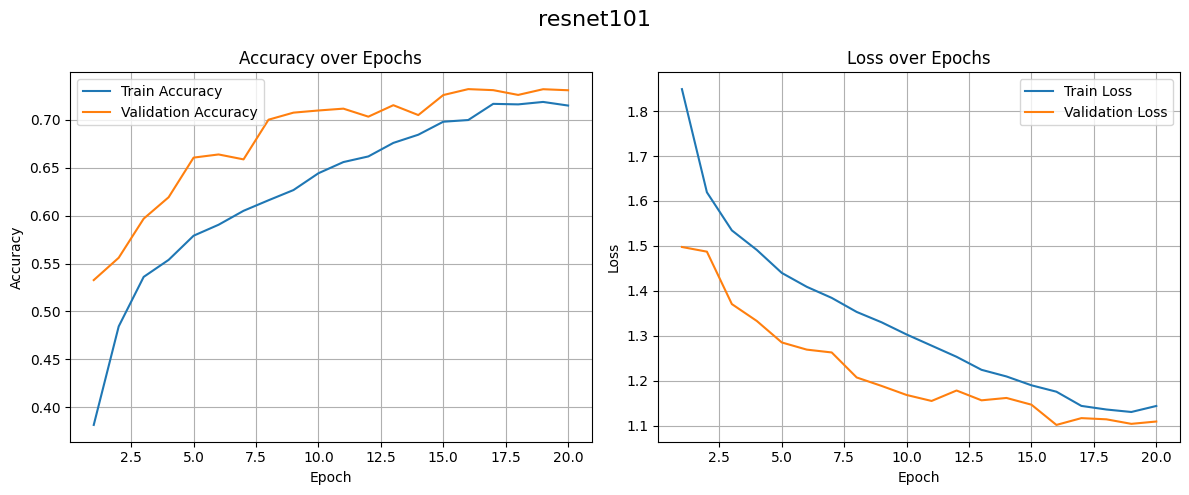

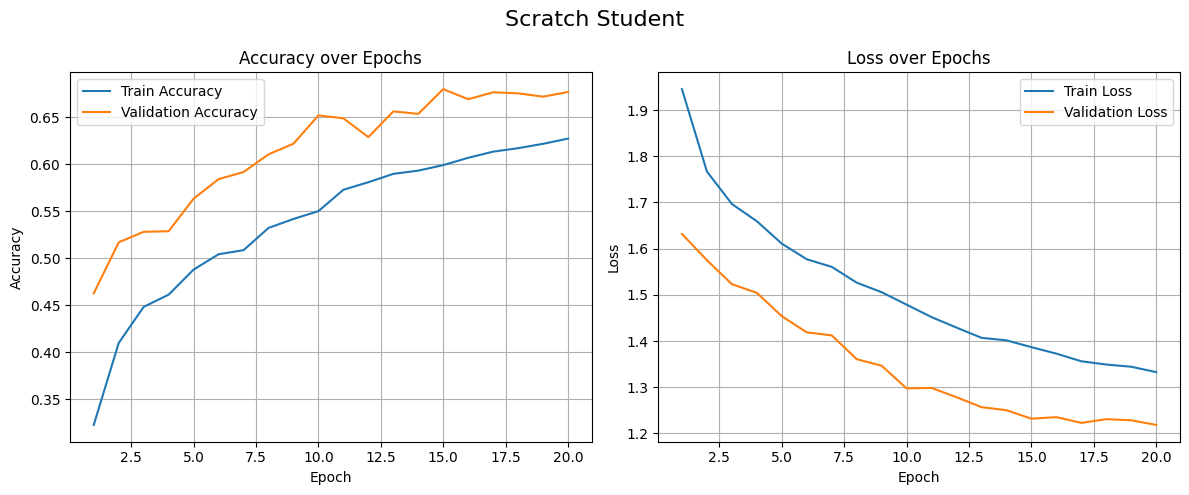

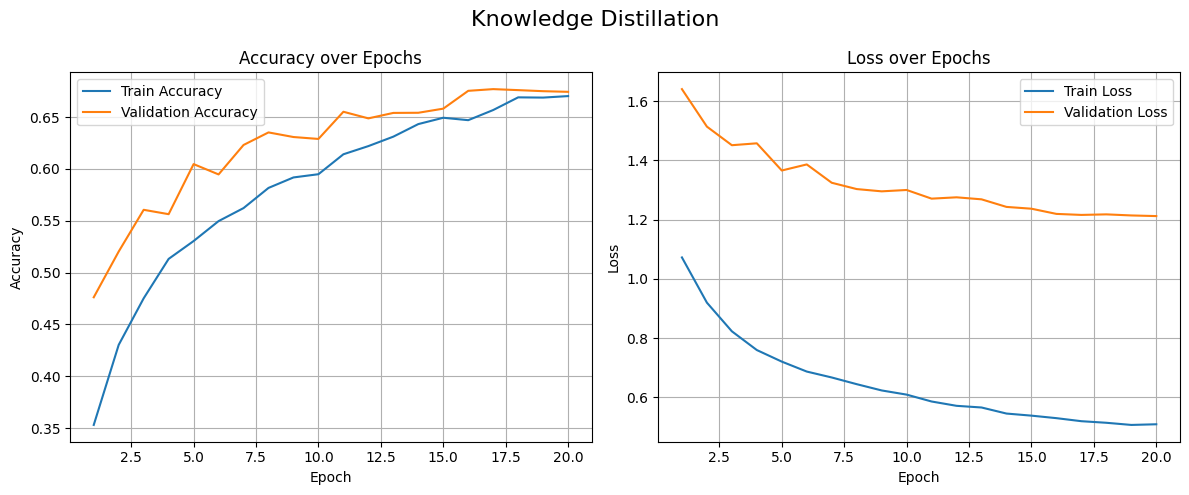

In [9]:

import matplotlib.pyplot as plt
def plot_history(history, title):
    # Unpack the history
    train_acc = [row[0] for row in history]
    train_loss = [row[1] for row in history]
    val_acc   = [row[2] for row in history]
    val_loss  = [row[3] for row in history]
    epochs = range(1, len(history) + 1)

    # Plotting
    plt.figure(figsize=(12, 5))

    # Subplot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.suptitle(f'{title}', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_history(history_resnet101, 'resnet101')
plot_history(history_scratch, 'Scratch Student')
plot_history(history_kd, 'Knowledge Distillation')